In [1]:
import pandas as pd
df = pd.read_csv('c:/data/mart/mart.csv')
df.head()

,seoul,incheon,gyungi,male,female,age10,age2030,age4050,age60,food,...,product,max_ta,max_ws,min_ta,avg_ta,avg_rhm,avg_ws,sum_rn,amount,class
0,1,0,0,0,1,1,0,0,0,1,...,0,4.0,3.5,-3.3,1.2,73,1.6,0.0,7,0
1,1,0,0,0,1,0,1,0,0,1,...,0,4.0,3.5,-3.3,1.2,73,1.6,0.0,655,1
2,1,0,0,0,1,0,1,0,0,1,...,0,4.0,3.5,-3.3,1.2,73,1.6,0.0,282,1
3,1,0,0,0,1,0,1,0,0,0,...,1,4.0,3.5,-3.3,1.2,73,1.6,0.0,35,0
4,1,0,0,0,1,0,1,0,0,0,...,0,4.0,3.5,-3.3,1.2,73,1.6,0.0,183,1


In [2]:
train_cols = df.columns[0:19]
X = df[train_cols]
y = df['class']
X.head()

,seoul,incheon,gyungi,male,female,age10,age2030,age4050,age60,food,drink,product,max_ta,max_ws,min_ta,avg_ta,avg_rhm,avg_ws,sum_rn
0,1,0,0,0,1,1,0,0,0,1,0,0,4.0,3.5,-3.3,1.2,73,1.6,0.0
1,1,0,0,0,1,0,1,0,0,1,0,0,4.0,3.5,-3.3,1.2,73,1.6,0.0
2,1,0,0,0,1,0,1,0,0,1,0,0,4.0,3.5,-3.3,1.2,73,1.6,0.0
3,1,0,0,0,1,0,1,0,0,0,0,1,4.0,3.5,-3.3,1.2,73,1.6,0.0
4,1,0,0,0,1,0,1,0,0,0,1,0,4.0,3.5,-3.3,1.2,73,1.6,0.0


In [3]:
import statsmodels.api as sm
model = sm.Logit(y,X)
result = model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.246488
         Iterations 9
                            Results: Logit
Model:                 Logit             Method:            MLE       
Dependent Variable:    class             Pseudo R-squared:  0.576     
Date:                  2026-01-29 11:58  AIC:               14827.2519
No. Observations:      30000             BIC:               14985.1220
Df Model:              18                Log-Likelihood:    -7394.6   
Df Residuals:          29981             LL-Null:           -17422.   
Converged:             1.0000            LLR p-value:       0.0000    
No. Iterations:        9.0000            Scale:             1.0000    
----------------------------------------------------------------------
         Coef.    Std.Err.      z    P>|z|      [0.025       0.975]   
----------------------------------------------------------------------
seoul   -0.6686 3159549.8830 -0.0000 1.0000 -6192604.6467 6192603.3095
inc

In [4]:
df.columns

Index(['seoul', 'incheon', 'gyungi', 'male', 'female', 'age10', 'age2030',
       'age4050', 'age60', 'food', 'drink', 'product', 'max_ta', 'max_ws',
       'min_ta', 'avg_ta', 'avg_rhm', 'avg_ws', 'sum_rn', 'amount', 'class'],
      dtype='object')

In [5]:
train_cols = ['seoul', 'incheon', 'gyungi', 'male', 'female', 'age10', 'age2030',
       'age4050', 'age60', 'food', 'drink', 'product', 'max_ta', 'max_ws',
       'min_ta', 'avg_ta', 'avg_rhm', 'avg_ws', 'sum_rn']
df['class'].value_counts()

class
0    21976
1     8024
Name: count, dtype: int64

In [6]:
#언더샘플링
from imblearn.under_sampling import RandomUnderSampler
X_sample, y_sample = RandomUnderSampler(random_state=0).fit_resample(X,y)
X_samp = pd.DataFrame(data=X_sample, columns=train_cols)
y_samp = pd.DataFrame(data=y_sample, columns=['class'])
df_samp = pd.concat([X_samp, y_samp], axis=1)
df_samp['class'].value_counts()

class
0    8024
1    8024
Name: count, dtype: int64

In [7]:
X = X_samp[train_cols]
y = y_samp['class']

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [9]:
########### (1) 로지스틱 회귀분석 ##############

In [10]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=0))
])
params = {
    'clf__C': [0.0001,0.001,0.01,0.1,1.0,10,100]
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X, y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__C': 0.1}
0.7358551078636412


In [11]:
#다양한 알고리즘별 정확도를 저장할 리스트
scores=[]

In [12]:
scores.append(grid.best_score_)
scores

[np.float64(0.7358551078636412)]

In [13]:
############ (2) 의사결정나무 #################

In [14]:
from sklearn.tree import DecisionTreeClassifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=0))
])
params = {
    'clf__max_depth': list(range(3,6))
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X, y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__max_depth': 4}
0.7468201993093885


In [15]:
scores.append(grid.best_score_)
scores

[np.float64(0.7358551078636412), np.float64(0.7468201993093885)]

In [16]:
tree = grid.best_estimator_['clf']

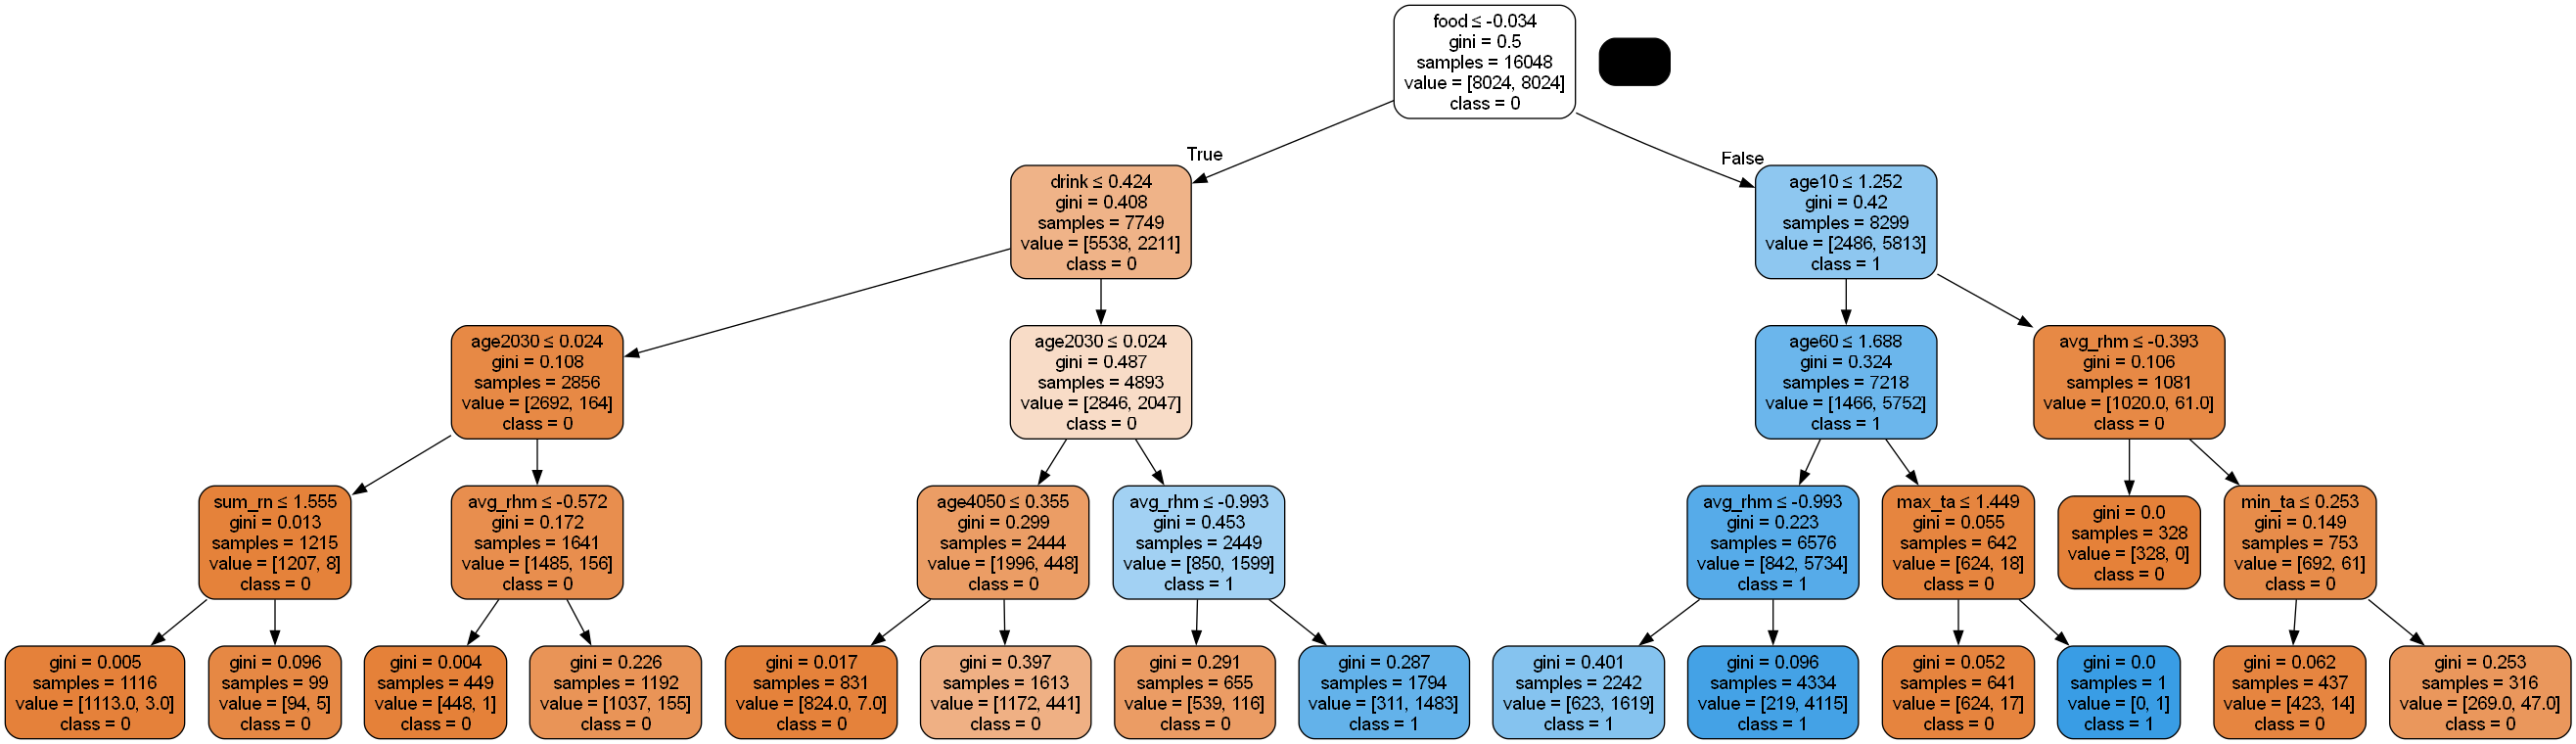

In [17]:
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image
dot_data = export_graphviz(tree, out_file=None, feature_names=train_cols, class_names=['0','1'], filled=True, rounded=True, special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

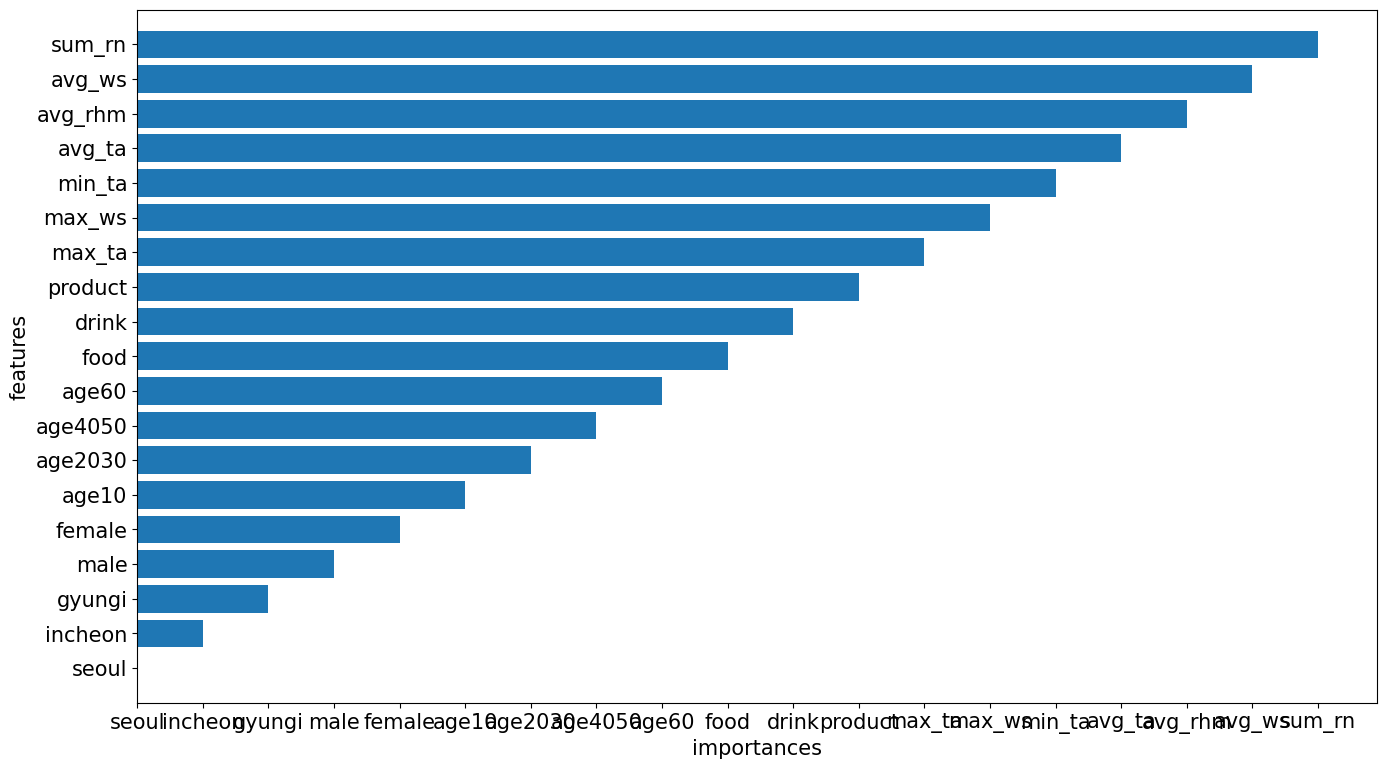

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tree(model):
    n_features = X.shape[1]
    plt.rcParams['figure.figsize']=(16,9)
    plt.barh(range(n_features), train_cols)
    plt.yticks(np.arange(n_features), train_cols)
    plt.xlabel('importances')
    plt.ylabel('features')
    plt.ylim(-1, n_features)

plot_tree(tree)

In [19]:
############# (3) 랜덤포레스트 ################

In [20]:
from sklearn.ensemble import RandomForestClassifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=0))
])
params = {
    'clf__max_depth': list(range(3,6)),
    'clf__n_estimators': list(range(10,110,10))
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X, y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__max_depth': 3, 'clf__n_estimators': 40}
0.6850649930781602


In [21]:
scores.append(grid.best_score_)
scores

[np.float64(0.7358551078636412),
 np.float64(0.7468201993093885),
 np.float64(0.6850649930781602)]

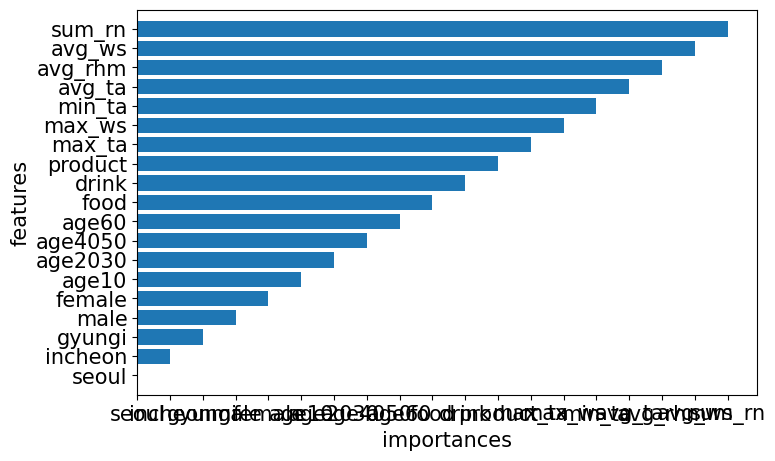

In [36]:
rf = grid.best_estimator_['clf']
plt.figure(figsize=(8,5))
plot_tree(rf)

In [23]:
############### (4) 사례기반추론 #################

In [24]:
from sklearn.neighbors import KNeighborsClassifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])
params = {
    'clf__n_neighbors': list(range(1,11))
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X,y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__n_neighbors': 10}
0.6092341946466834


In [25]:
scores.append(grid.best_score_)
scores

[np.float64(0.7358551078636412),
 np.float64(0.7468201993093885),
 np.float64(0.6850649930781602),
 np.float64(0.6092341946466834)]

In [26]:
################# (5) 인공신경망 ####################

In [27]:
from sklearn.neural_network import MLPClassifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(random_state=0, max_iter=5000))
])
params = {
    'clf__hidden_layer_sizes': [(50,), (100,)]
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X,y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__hidden_layer_sizes': (50,)}
0.5447420515320358


In [28]:
scores.append(grid.best_score_)
scores

[np.float64(0.7358551078636412),
 np.float64(0.7468201993093885),
 np.float64(0.6850649930781602),
 np.float64(0.6092341946466834),
 np.float64(0.5447420515320358)]

In [29]:
################ (6) SVM #####################

In [30]:
from sklearn.svm import SVC
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(random_state=0))
])
params = {
    'clf__C': [0.01, 0.1],
    'clf__gamma': [0.001,0.01]
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X,y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__C': 0.1, 'clf__gamma': 0.01}
0.6886822179473965


In [31]:
scores.append(grid.best_score_)
scores

[np.float64(0.7358551078636412),
 np.float64(0.7468201993093885),
 np.float64(0.6850649930781602),
 np.float64(0.6092341946466834),
 np.float64(0.5447420515320358),
 np.float64(0.6886822179473965)]

In [32]:
############### 성능비교 #################

In [33]:
methods = ['LOGIT', 'Tree', 'RF', 'KNN', 'ANN', 'SVM']
scores_arr = np.array(scores) #검증용 데이터셋의 정확도
max_rate = np.max(scores_arr) #가장 높은 정확도
idx = np.argmax(scores_arr) #최대값의 인덱스

print(methods)
print('최적의 모형:', methods[idx])
print('최적의 정확도:', max_rate)

['LOGIT', 'Tree', 'RF', 'KNN', 'ANN', 'SVM']
최적의 모형: Tree
최적의 정확도: 0.7468201993093885


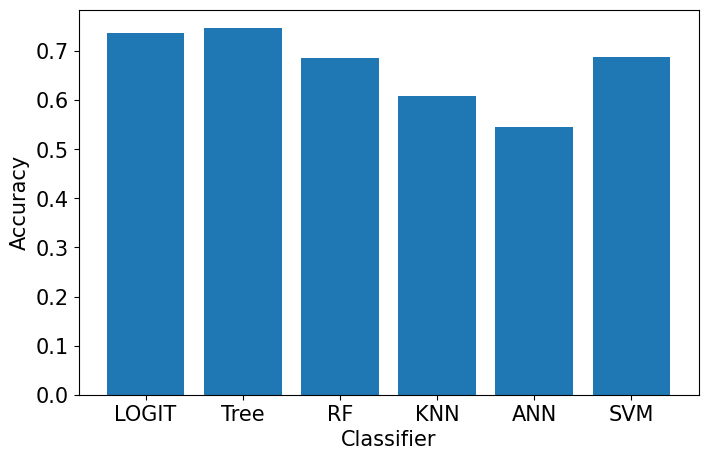

In [35]:
plt.rcParams['font.size']=15
plt.figure(figsize=(8,5))
plt.bar(methods, scores_arr)
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.show()